# RetailMax: Outlier Detection with PyOD

**Executive question:** When RetailMax finds unusual customer behaviour, is it a data error, business risk, bulk purchase, or high-value opportunity?

This notebook uses PyOD's Isolation Forest implementation and emphasizes the sequence **Detect → Diagnose → Decide**.

## Learning outcomes
Participants will:
1. prepare relevant retail variables;
2. fit a PyOD Isolation Forest model;
3. examine anomaly labels and scores;
4. interpret unusual customer profiles; and
5. recommend managerial actions.

In [1]:
# Run once in a fresh environment such as Google Colab.
%pip install -q pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.9 MB/s eta 0:00:00


## 1. Load libraries and RetailMax data

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from pyod.models.iforest import IForest

DATA_FILE = Path("RetailMax_Customer_Analytics.csv")
if not DATA_FILE.exists():
    DATA_FILE = Path("/content/RetailMax_Customer_Data.csv")
assert DATA_FILE.exists(), "Place RetailMax_Customer_Analytics.csv beside the notebook."

df = pd.read_csv(DATA_FILE)
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Rows: 800 | Columns: 15


,Customer_ID,Age,Annual_Income_INR,Region,Preferred_Channel,Loyalty_Status,Primary_Category,Purchase_Frequency,Average_Basket_Value_INR,Annual_Spend_INR,Average_Discount_Rate,Return_Rate,Customer_Satisfaction_10,Estimated_Gross_Profit_INR,Estimated_Profit_Margin
0,RM0001,37.0,571000.0,West,Online,Platinum,Grocery,14,3011.52,39314.28,21.9,10.9,9.3,6491.12,16.5
1,RM0002,40.0,996000.0,North,Omnichannel,Silver,Grocery,7,1475.50,10898.01,16.7,19.7,5.4,1549.84,14.2
2,RM0003,38.0,523000.0,North,Store,NaN,Grocery,20,1497.42,29015.26,6.9,6.8,6.2,6469.93,22.3
3,RM0004,18.0,1051000.0,North,Store,Silver,Grocery,48,2040.00,95467.31,8.4,13.8,8.7,18101.56,19.0
4,RM0005,53.0,279000.0,West,Store,NaN,Fashion,3,1353.56,4237.77,13.4,5.0,7.1,1562.33,36.9


## 2. Select variables linked to unusual purchasing and profitability behaviour

In [4]:
features = [
    "Purchase_Frequency",
    "Average_Basket_Value_INR",
    "Annual_Spend_INR",
    "Average_Discount_Rate",
    "Return_Rate"
]
df[features].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Purchase_Frequency,800.0,16.54,10.33,1.00,10.00,15.00,21.00,103.00
Average_Basket_Value_INR,800.0,4603.61,24980.54,363.83,1780.38,2287.07,2946.35,355857.34
Annual_Spend_INR,800.0,51647.92,118914.20,1518.23,20665.77,33359.73,51357.24,1832460.64
Average_Discount_Rate,800.0,15.34,9.03,0.40,8.40,13.75,20.90,55.90
Return_Rate,774.0,10.77,8.92,0.10,4.50,9.00,14.40,74.30


### Why these variables?
- Frequency and basket value describe purchasing behaviour.
- Annual spend indicates customer value.
- Discount rate can signal promotion dependence or misuse.
- Return rate can signal dissatisfaction, process problems, or abuse.

**Interpretation**

The descriptive statistics show several strong indications of unusual observations:

Maximum purchase frequency is 103, compared with a median of 15.
Maximum basket value is approximately ₹356,000, compared with a median of about ₹2,287.
Maximum annual spend is approximately ₹1.83 million, compared with a median of about ₹33,360.
Return rates reach 74.3%.
Discount rates reach 55.9%.

The large differences between means, medians, and maximum values indicate strongly right-skewed distributions. Some customers have exceptionally large baskets or annual spending, while others have unusually high discount

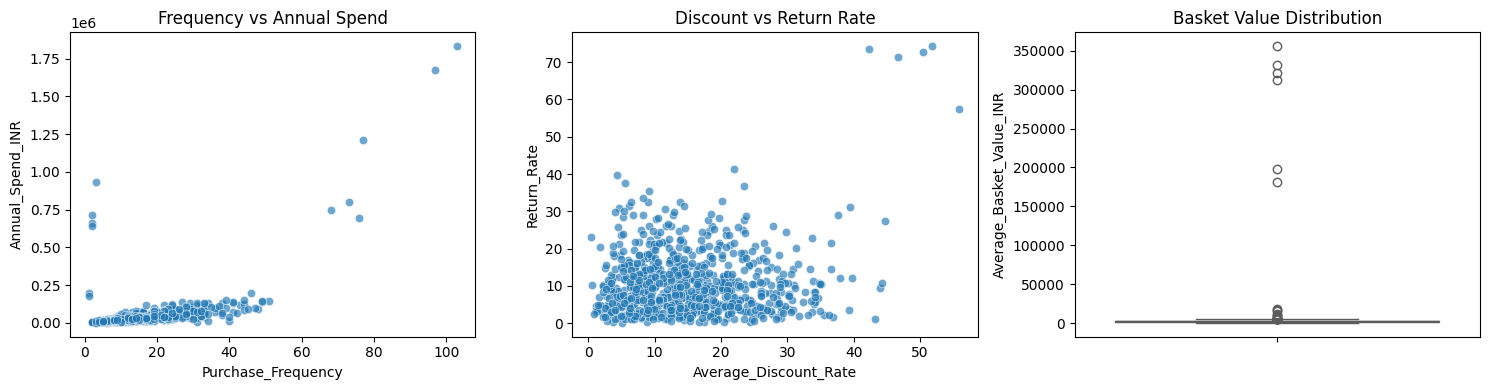

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.scatterplot(data=df, x="Purchase_Frequency", y="Annual_Spend_INR", ax=axes[0], alpha=.65)
sns.scatterplot(data=df, x="Average_Discount_Rate", y="Return_Rate", ax=axes[1], alpha=.65)
sns.boxplot(data=df, y="Average_Basket_Value_INR", ax=axes[2], color="#5B9BD5")
axes[0].set_title("Frequency vs Annual Spend")
axes[1].set_title("Discount vs Return Rate")
axes[2].set_title("Basket Value Distribution")
plt.tight_layout()
plt.show()

**Interpretation**

The plots reveal three types of potential anomalies:

Customers with exceptionally high purchase frequency and annual spending
Customers with unusually high discount and return rates
Customers with extremely high average basket values

Most customer observations are concentrated in relatively compact ranges. A small number occur far from those concentrations, making them plausible candidates for investigation.

## 3. Prepare the feature matrix
Median imputation is used only to make the selected numeric inputs complete. Standardization prevents INR-valued variables from dominating because of their units.

In [6]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(df[features])
X_scaled = scaler.fit_transform(X_imputed)
print("Model matrix shape:", X_scaled.shape)

Model matrix shape: (800, 5)


## 4. Fit PyOD Isolation Forest
`contamination=0.03` asks the model to flag approximately 3% of records. Treat this as a teaching assumption to be tested, not as a fact about RetailMax.

In [7]:
model = IForest(contamination=0.03, random_state=42)
model.fit(X_scaled)

results = df.copy()
results["Outlier_Flag"] = model.labels_
results["Anomaly_Score"] = model.decision_scores_
results["Outlier_Label"] = results["Outlier_Flag"].map({0:"Typical", 1:"Flagged"})

print(results["Outlier_Label"].value_counts())

Outlier_Label
Typical    776
Flagged     24
Name: count, dtype: int64


**Interpretation**

The model classified:

776 customers as typical
24 customers as flagged
3% of customers as outliers

This outcome is directly connected to contamination=0.03. The code instructed the model to identify approximately 3% of observations as anomalous.

Therefore, the result does not mean that the model independently discovered that exactly 3% of RetailMax customers are problematic. The 3% is a modelling assumption chosen for the exercise.

random_state=42 makes the result reproducible when the same data, package version, and implementation are used.

## 5. Inspect the most unusual customers
A higher anomaly score indicates that a record is more unusual relative to the fitted data.

In [15]:
review_cols = ["Customer_ID"] + features + [
    "Estimated_Gross_Profit_INR", "Estimated_Profit_Margin",
    "Outlier_Label", "Anomaly_Score"
]
flagged = results.loc[results["Outlier_Flag"] == 1, review_cols].sort_values(
    "Anomaly_Score", ascending=False
)
flagged.head(7).round(4)

,Customer_ID,Purchase_Frequency,Average_Basket_Value_INR,Annual_Spend_INR,Average_Discount_Rate,Return_Rate,Estimated_Gross_Profit_INR,Estimated_Profit_Margin,Outlier_Label,Anomaly_Score
533,RM0534,97,17253.33,1673573.01,17.6,4.4,493285.64,29.5,Flagged,0.2083
397,RM0398,103,17790.88,1832460.64,8.5,2.7,432407.57,23.6,Flagged,0.2076
321,RM0322,2,355857.34,711714.68,12.7,9.8,138641.31,19.5,Flagged,0.2058
408,RM0409,3,311892.66,935677.98,15.7,5.9,189977.25,20.3,Flagged,0.2028
754,RM0755,2,321150.60,642301.20,20.9,7.2,209348.44,32.6,Flagged,0.1989
741,RM0742,2,331633.99,663267.98,10.1,19.5,106792.78,16.1,Flagged,0.1943
121,RM0122,77,15731.96,1211360.92,21.7,4.2,234652.72,19.4,Flagged,0.1797


**Interpretation**

The model has detected multiple forms of unusual behaviour.

RM0534 and RM0398 have exceptionally high purchase frequency and annual spending. These records could represent valuable customers, wholesale-like activity, duplicate transaction aggregation, or another special context requiring review.

RM0322, RM0409, RM0755, and RM0742 make only two or three purchases but have extraordinarily high basket values. These observations resemble bulk purchases or large institutional transactions more than typical individual consumer behaviour.

RM0412 has a different anomaly profile. The customer has a 50.4% average discount rate, a 72.6% return rate, and a negative estimated profit margin. This case presents an operational and profitability concern rather than a high-value pattern.

A high anomaly score means that the combination of features is unusual. It does not explain why the observation is unusual.

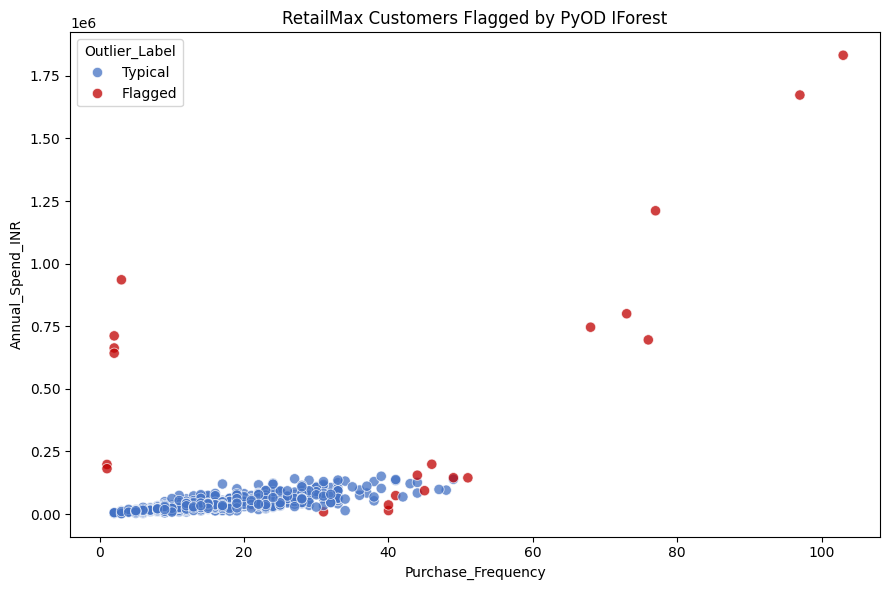

In [9]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=results, x="Purchase_Frequency", y="Annual_Spend_INR",
    hue="Outlier_Label", palette={"Typical":"#4472C4", "Flagged":"#C00000"},
    alpha=.75, s=55
)
plt.title("RetailMax Customers Flagged by PyOD IForest")
plt.tight_layout()
plt.show()

## 6. Diagnose the flagged cases with transparent business rules


Domain knowledge

Data profiling

Business policies

SME (subject matter expert) input

Statistical thresholds

In [10]:
income_upper = results["Annual_Income_INR"].quantile(.99)
spend_upper = results["Annual_Spend_INR"].quantile(.99)
basket_upper = results["Average_Basket_Value_INR"].quantile(.99)

def suggested_interpretation(r):
    if pd.notna(r["Age"]) and (r["Age"] < 18 or r["Age"] > 90):
        return "Possible data-entry error"
    if pd.notna(r["Annual_Income_INR"]) and r["Annual_Income_INR"] > income_upper:
        return "Possible data-entry error"
    if pd.notna(r["Return_Rate"]) and r["Return_Rate"] >= .50 and r["Average_Discount_Rate"] >= .40:
        return "Potential abuse/fraud risk"
    if r["Average_Basket_Value_INR"] >= basket_upper and r["Purchase_Frequency"] <= 3:
        return "Unusual bulk purchase"
    if r["Annual_Spend_INR"] >= spend_upper and (pd.isna(r["Return_Rate"]) or r["Return_Rate"] < .10):
        return "High-value opportunity"
    return "Investigate context"

results["Suggested_Interpretation"] = results.apply(suggested_interpretation, axis=1)
results.loc[results["Outlier_Flag"] == 1, [
    "Customer_ID", "Anomaly_Score", "Suggested_Interpretation"
]].sort_values("Anomaly_Score", ascending=False).head(20)

,Customer_ID,Anomaly_Score,Suggested_Interpretation
533,RM0534,0.208253,Potential abuse/fraud risk
397,RM0398,0.207593,Potential abuse/fraud risk
321,RM0322,0.205802,Potential abuse/fraud risk
408,RM0409,0.202785,Potential abuse/fraud risk
754,RM0755,0.198878,Potential abuse/fraud risk
741,RM0742,0.194298,Potential abuse/fraud risk
121,RM0122,0.179679,Potential abuse/fraud risk
411,RM0412,0.172811,Potential abuse/fraud risk
514,RM0515,0.162535,Potential abuse/fraud risk
335,RM0336,0.154548,Potential abuse/fraud risk


## 7. Convert model output into managerial action

In [11]:
action_map = {
    "Possible data-entry error":"Verify and correct source data",
    "Potential abuse/fraud risk":"Escalate for fraud or returns review",
    "Unusual bulk purchase":"Confirm legitimacy and understand use case",
    "High-value opportunity":"Review for retention or premium service",
    "Investigate context":"Monitor and investigate supporting records"
}
results["Recommended_Action"] = results["Suggested_Interpretation"].map(action_map)

managerial_review = results.loc[results["Outlier_Flag"] == 1, [
    "Customer_ID", "Anomaly_Score", "Suggested_Interpretation", "Recommended_Action"
]].sort_values("Anomaly_Score", ascending=False)
managerial_review.head(20)

,Customer_ID,Anomaly_Score,Suggested_Interpretation,Recommended_Action
533,RM0534,0.208253,Potential abuse/fraud risk,Escalate for fraud or returns review
397,RM0398,0.207593,Potential abuse/fraud risk,Escalate for fraud or returns review
321,RM0322,0.205802,Potential abuse/fraud risk,Escalate for fraud or returns review
408,RM0409,0.202785,Potential abuse/fraud risk,Escalate for fraud or returns review
754,RM0755,0.198878,Potential abuse/fraud risk,Escalate for fraud or returns review
741,RM0742,0.194298,Potential abuse/fraud risk,Escalate for fraud or returns review
121,RM0122,0.179679,Potential abuse/fraud risk,Escalate for fraud or returns review
411,RM0412,0.172811,Potential abuse/fraud risk,Escalate for fraud or returns review
514,RM0515,0.162535,Potential abuse/fraud risk,Escalate for fraud or returns review
335,RM0336,0.154548,Potential abuse/fraud risk,Escalate for fraud or returns review


## 8. Sensitivity check: Does the assumed anomaly proportion matter?
The flagged set depends partly on the contamination assumption. Compare several assumptions before making decisions.

In [12]:
sensitivity=[]
for contamination in [0.01, 0.03, 0.05]:
    m = IForest(contamination=contamination, random_state=42)
    m.fit(X_scaled)
    sensitivity.append({
        "Contamination_Assumption": contamination,
        "Flagged_Customers": int(m.labels_.sum()),
        "Flagged_Percent": 100*m.labels_.mean()
    })
pd.DataFrame(sensitivity)

,Contamination_Assumption,Flagged_Customers,Flagged_Percent
0,0.01,8,1.0
1,0.03,24,3.0
2,0.05,40,5.0


## 9. Participant decision activity
Select five flagged customers and decide:
- Is the case most likely an error, risk, bulk purchase, opportunity, or unresolved?
- What supporting evidence is required?
- What action should RetailMax take?
- What is the cost of a false alarm?

**Key principle:** PyOD flags unusual combinations. It does not prove fraud, error, or customer value.

In [13]:
OUTPUT_FILE = "RetailMax_PyOD_Results.csv"
results.to_csv(OUTPUT_FILE, index=False)
print(f"Saved: {OUTPUT_FILE}")

Saved: RetailMax_PyOD_Results.csv
